# 文件: chart_18_1.py

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_66232\2374061980.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=1, frameon=False)


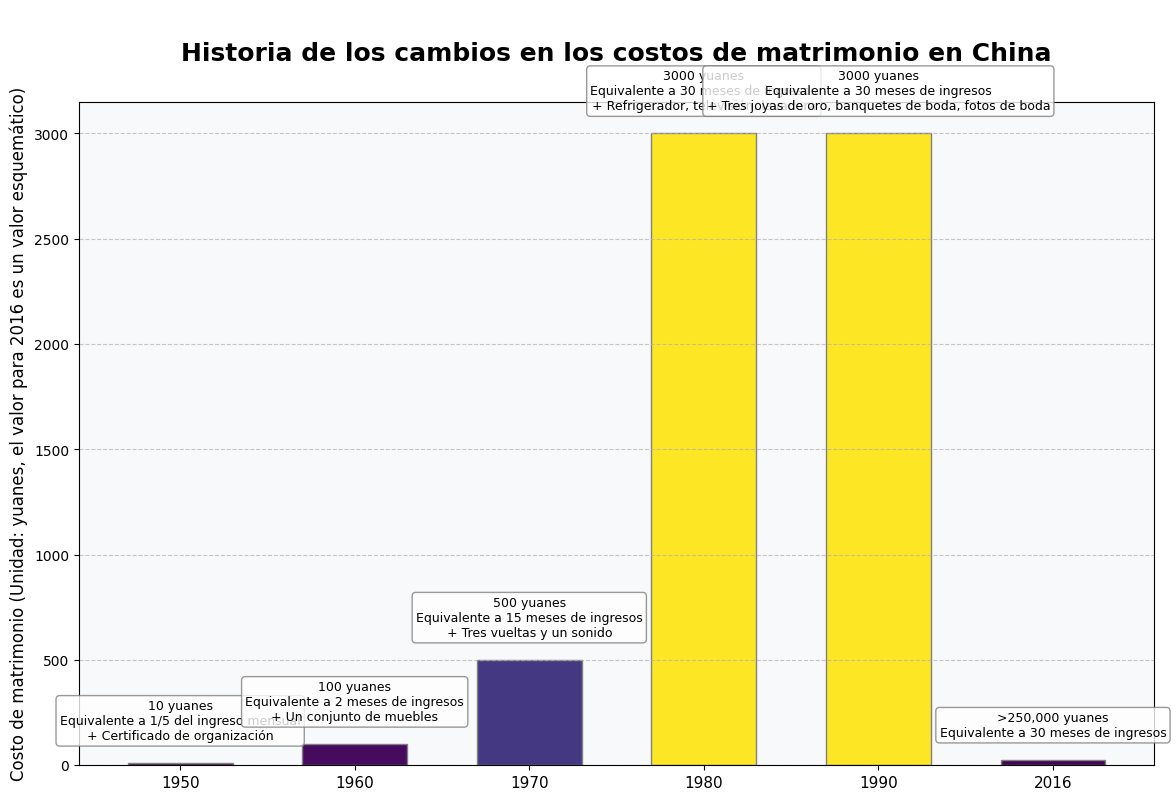

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
años = np.array([1950, 1960, 1970, 1980, 1990, 2016])
costos = np.array([10, 100, 500, 3000, 3000, 25])  # El valor para 2016 es un valor esquemático
etiquetas = [
    "10 yuanes\nEquivalente a 1/5 del ingreso mensual\n+ Certificado de organización",
    "100 yuanes\nEquivalente a 2 meses de ingresos\n+ Un conjunto de muebles",
    "500 yuanes\nEquivalente a 15 meses de ingresos\n+ Tres vueltas y un sonido",
    "3000 yuanes\nEquivalente a 30 meses de ingresos\n+ Refrigerador, televisión, lavadora",
    "3000 yuanes\nEquivalente a 30 meses de ingresos\n+ Tres joyas de oro, banquetes de boda, fotos de boda",
    ">250,000 yuanes\nEquivalente a 30 meses de ingresos"
]

# Crear una figura y ejes, aumentar el espacio superior
fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(top=0.85)  # Ajustar el espaciado superior

# Dibujar un gráfico de barras de color degradado (usando un mapa de colores)
cmap = plt.cm.viridis
norm = plt.Normalize(min(costos), max(costos))
colores = [cmap(norm(c)) for c in costos]
barras = ax.bar(np.arange(len(años)), costos, width=0.6, color=colores, edgecolor='gray')

# Establecer el título y las etiquetas
ax.set_title("Historia de los cambios en los costos de matrimonio en China", fontsize=18, fontweight='bold', pad=30)
ax.set_ylabel("Costo de matrimonio (Unidad: yuanes, el valor para 2016 es un valor esquemático)", fontsize=12)
ax.set_xticks(np.arange(len(años)))
ax.set_xticklabels(años, fontsize=11)

# Agregar líneas de cuadrícula y color de fondo
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_facecolor('#f8f9fa')

# Optimizar las anotaciones de texto - Usar anotaciones con caja en lugar de anotaciones directas en las barras
for i, (barra, etiqueta) in enumerate(zip(barras, etiquetas)):
    altura = barra.get_height()
    ax.annotate(etiqueta,
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 15),  # Desplazamiento vertical
                textcoords="offset points",
                ha='center', va='bottom',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                fontsize=9)

# Agregar una leyenda
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=1, frameon=False)

plt.tight_layout()
plt.show()

# 文件: chart_18_2.py

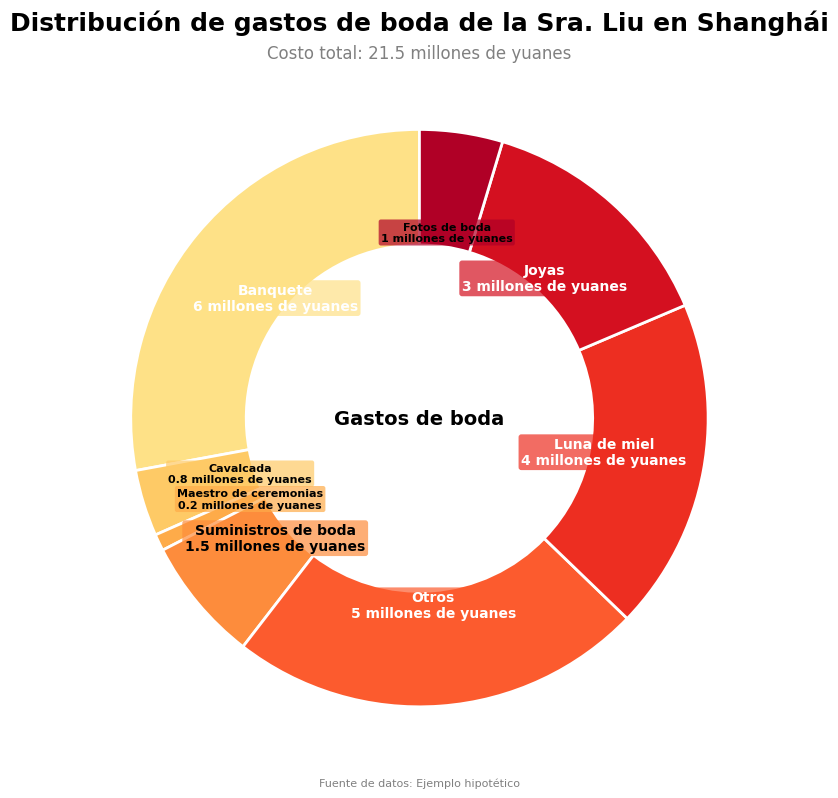

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
etiquetas = ["Banquete", "Cavalcada", "Maestro de ceremonias", "Suministros de boda", "Otros", "Luna de miel", "Joyas", "Fotos de boda"]
tamaños = [6, 0.8, 0.2, 1.5, 5, 4, 3, 1]
costo_total = sum(tamaños)  # Costo total

# Esquema de colores optimizado (utilizando colores de gradiente más armoniosos)
colores = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(etiquetas)))

# Crear un lienzo y un sub - gráfico
fig, ax = plt.subplots(figsize=(10, 8))

# Dibujar un gráfico de dona
porciones, textos, textos_automaticos = ax.pie(
    tamaños, 
    labels=None,  # No mostrar etiquetas directamente en el gráfico
    colors=colores,
    autopct='',  # No mostrar valores por ahora
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)  # Aumentar el ancho del anillo y agregar un borde blanco
)

# Personalizar etiquetas: mostrar tanto el nombre como la cantidad, y ajustar inteligentemente la posición y el color
for i, (porcion, etiqueta, tamaño) in enumerate(zip(porciones, etiquetas, tamaños)):
    # Calcular la posición del texto
    theta = (porcion.theta2 + porcion.theta1) / 2
    x = 0.65 * np.cos(np.radians(theta))  # 0.65 controla la posición radial
    y = 0.65 * np.sin(np.radians(theta))
    
    # Ajustar el estilo del texto según el tamaño del sector
    tamaño_texto = 10 if tamaño / costo_total > 0.05 else 8  # Usar una fuente más pequeña para sectores pequeños
    
    # Contenido del texto
    texto = f"{etiqueta}\n{ tamaño} millones de yuanes"
    
    # Ajustar el color del texto (usar texto blanco para sectores oscuros y texto negro para sectores claros)
    color = 'white' if i in [0, 4, 5, 6] else 'black'
    
    # Agregar texto
    ax.text(x, y, texto, ha='center', va='center', fontsize=tamaño_texto, 
            fontweight='bold', color=color, bbox=dict(
                boxstyle="round,pad=0.2", 
                fc=colores[i], 
                ec='none', 
                alpha=0.7
            ))

# Establecer el título
ax.set_title("Distribución de gastos de boda de la Sra. Liu en Shanghái", fontsize=18, fontweight='bold', pad=20)
subtitulo = f"Costo total: {costo_total} millones de yuanes"
plt.figtext(0.5, 0.92, subtitulo, ha='center', fontsize=12, color='gray')

# Agregar texto en el centro
circulo_centro = plt.Circle((0, 0), 0.2, fc='white')
ax.add_patch(circulo_centro)
ax.text(0, 0, "Gastos de boda", ha='center', va='center', fontsize=14, fontweight='bold')

# Ajustar el diseño
plt.tight_layout()

# Agregar la fuente de datos
plt.figtext(0.5, 0.01, "Fuente de datos: Ejemplo hipotético", ha='center', fontsize=8, color='gray')

plt.show()

# 文件: chart_18_3.py

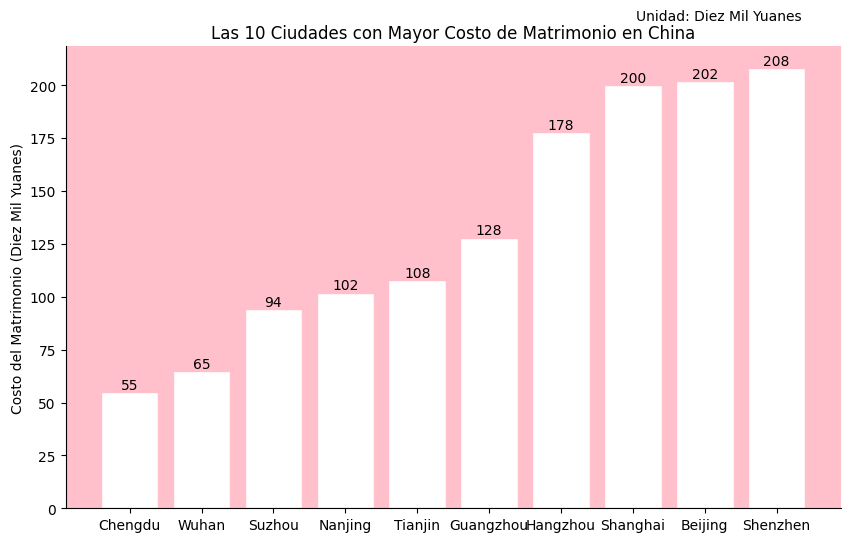

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las ciudades
ciudades = ["Chengdu", "Wuhan", "Suzhou", "Nanjing", "Tianjin", "Guangzhou", "Hangzhou", "Shanghai", "Beijing", "Shenzhen"]
# Costo del matrimonio (unidad: diez mil yuanes)
costos = [55, 65, 94, 102, 108, 128, 178, 200, 202, 208]

x = np.arange(len(ciudades))  # Se utiliza para establecer la posición del gráfico de barras en el eje x

# Crear un lienzo y un objeto de eje
fig, ax = plt.subplots(figsize=(10, 6))
# Dibujar un gráfico de barras, establecer el color en blanco y el borde en rosa
barras = ax.bar(x, costos, color='white', edgecolor='pink')

# Establecer las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(ciudades)
# Establecer la etiqueta del eje y
ax.set_ylabel("Costo del Matrimonio (Diez Mil Yuanes)")
# Establecer el título
ax.set_title("Las 10 Ciudades con Mayor Costo de Matrimonio en China")
# Establecer la unidad que se mostrará junto al título
ax.text(0.95, 1.05, "Unidad: Diez Mil Yuanes", transform=ax.transAxes, ha='right', va='bottom')

# Etiquetar los valores en cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width() / 2, altura, f'{altura}',
            ha='center', va='bottom')

# Establecer el color de fondo en rosa
ax.set_facecolor('pink')
# Eliminar los bordes superior y derecho
for espina in ['top', 'right']:
    ax.spines[espina].set_visible(False)

plt.show()

# 文件: chart_18_4.py

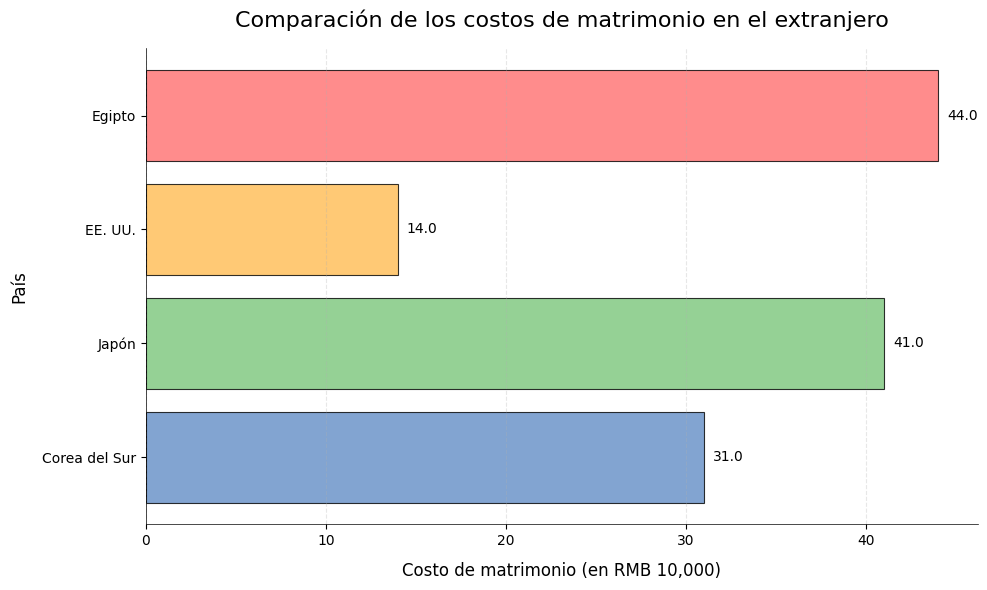

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
paises = ["Corea del Sur", "Japón", "EE. UU.", "Egipto"]
costos = [31, 41, (11 + 17) / 2, 44]  # Tomar el promedio del rango para EE. UU.

# Esquema de colores
colores = ['#638EC6', '#7BC67B', '#FFBC52', '#FF6F6F']

# Crear un lienzo y un subgráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar un gráfico de barras horizontales, agregar transparencia y bordes
barras = ax.barh(paises, costos, color=colores, alpha=0.8, edgecolor='black', linewidth=0.8)

# Agregar un título y etiquetas
ax.set_title("Comparación de los costos de matrimonio en el extranjero", fontsize=16, pad=15)
ax.set_xlabel("Costo de matrimonio (en RMB 10,000)", fontsize=12, labelpad=10)
ax.set_ylabel("País", fontsize=12, labelpad=10)

# Agregar etiquetas numéricas
for barra in barras:
    ancho = barra.get_width()
    ax.text(ancho + 0.5, barra.get_y() + barra.get_height()/2,
            f'{ancho:.1f}', ha='left', va='center', fontsize=10)

# Establecer el estilo del eje
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# Establecer el estilo de las marcas
ax.tick_params(axis='both', which='major', labelsize=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

# Agregar una cuadrícula de fondo
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()